In [1]:
import pandas as pd
import numpy as np

In [59]:
df = pd.read_csv(r"C:\Users\Akankssha\Downloads\swiggy_demographic.csv")

df.head()

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138


## Data Cleaning

In [60]:
df.shape

(45502, 26)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45502 entries, 0 to 45501
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rider_id              45502 non-null  object 
 1   age                   43648 non-null  float64
 2   ratings               43594 non-null  float64
 3   restaurant_latitude   41872 non-null  float64
 4   restaurant_longitude  41872 non-null  float64
 5   delivery_latitude     41872 non-null  float64
 6   delivery_longitude    41872 non-null  float64
 7   order_date            45502 non-null  object 
 8   weather               44977 non-null  object 
 9   traffic               44992 non-null  object 
 10  vehicle_condition     45502 non-null  int64  
 11  type_of_order         45502 non-null  object 
 12  type_of_vehicle       45502 non-null  object 
 13  multiple_deliveries   44509 non-null  float64
 14  festival              45274 non-null  object 
 15  city_type          

In [62]:
df.isnull().sum()

rider_id                   0
age                     1854
ratings                 1908
restaurant_latitude     3630
restaurant_longitude    3630
delivery_latitude       3630
delivery_longitude      3630
order_date                 0
weather                  525
traffic                  510
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries      993
festival                 228
city_type               1198
time_taken                 0
city_name                  0
order_day                  0
order_month                0
order_day_of_week          0
is_weekend                 0
pickup_time_minutes     1640
order_time_hour         1640
order_time_of_day          0
distance                3630
dtype: int64

In [63]:
num_cols = [
    'age',
    'ratings',
    'restaurant_latitude',
    'restaurant_longitude',
    'delivery_latitude',
    'delivery_longitude',
    'multiple_deliveries',
    'pickup_time_minutes',
    'order_time_hour',
    'distance'
]

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\Akankssha\AppData\Local\Temp\ipykernel_35552\3370239420.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [64]:
cat_cols = [
    'weather',
    'traffic',
    'festival',
    'city_type'
]

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\Akankssha\AppData\Local\Temp\ipykernel_35552\4277823525.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [65]:
df.isnull().sum()

rider_id                0
age                     0
ratings                 0
restaurant_latitude     0
restaurant_longitude    0
delivery_latitude       0
delivery_longitude      0
order_date              0
weather                 0
traffic                 0
vehicle_condition       0
type_of_order           0
type_of_vehicle         0
multiple_deliveries     0
festival                0
city_type               0
time_taken              0
city_name               0
order_day               0
order_month             0
order_day_of_week       0
is_weekend              0
pickup_time_minutes     0
order_time_hour         0
order_time_of_day       0
distance                0
dtype: int64

In [66]:
# Numerical Columns
num_cols = [
    'age',
    'ratings',
    'restaurant_latitude',
    'restaurant_longitude',
    'delivery_latitude',
    'delivery_longitude',
    'multiple_deliveries',
    'pickup_time_minutes',
    'order_time_hour',
    'distance'
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical Columns
cat_cols = [
    'weather',
    'traffic',
    'festival',
    'city_type'
]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [67]:
df.isnull().sum()

rider_id                0
age                     0
ratings                 0
restaurant_latitude     0
restaurant_longitude    0
delivery_latitude       0
delivery_longitude      0
order_date              0
weather                 0
traffic                 0
vehicle_condition       0
type_of_order           0
type_of_vehicle         0
multiple_deliveries     0
festival                0
city_type               0
time_taken              0
city_name               0
order_day               0
order_month             0
order_day_of_week       0
is_weekend              0
pickup_time_minutes     0
order_time_hour         0
order_time_of_day       0
distance                0
dtype: int64

In [68]:
df.duplicated().sum()

np.int64(0)

In [69]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = [
    'weather',
    'traffic',
    'type_of_order',
    'type_of_vehicle',
    'festival',
    'city_type',
    'city_name',
    'order_day_of_week',
    'order_time_of_day'
]

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,4,0,...,24,10,19,3,2,1,15.0,11.0,3,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,3,1,...,33,3,25,3,0,0,5.0,19.0,2,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,2,2,...,26,3,19,3,2,1,15.0,8.0,3,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,4,3,...,21,6,5,4,5,0,10.0,18.0,2,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,0,0,...,30,5,26,3,2,1,15.0,13.0,1,6.210138


In [70]:
df = df.drop("rider_id", axis=1)

In [71]:
df["order_date"] = pd.to_datetime(df["order_date"])

df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["day"] = df["order_date"].dt.day

df.drop("order_date", axis=1, inplace=True)

## Data Visualization

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='time_taken', ylabel='Count'>

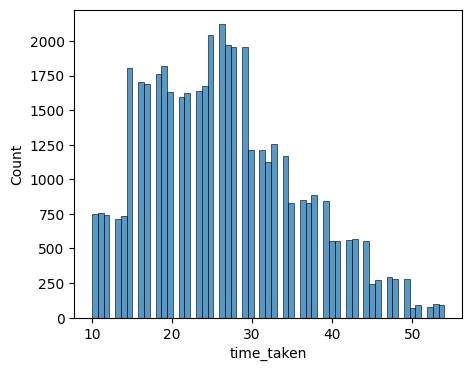

In [15]:
plt.figure(figsize=(5,4))
sns.histplot(df['time_taken'])

<Axes: xlabel='distance', ylabel='time_taken'>

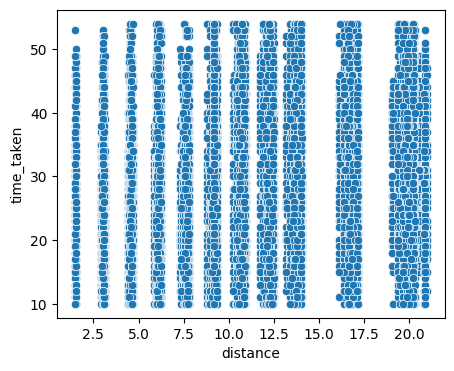

In [16]:
plt.figure(figsize=(5,4))
sns.scatterplot(data=df, x='distance', y='time_taken')

<Axes: >

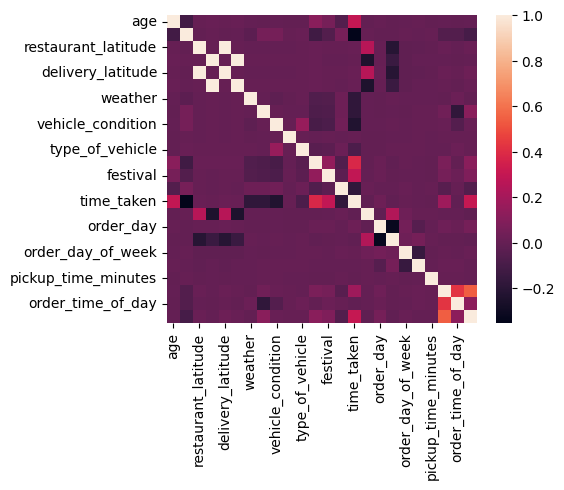

In [17]:
plt.figure(figsize=(5,4))
sns.heatmap(df.corr(numeric_only=True))

## Data Train Test and Split

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X = df.drop('time_taken', axis=1)
y = df['time_taken']

In [72]:
num_cols = [
    'age',
    'ratings',
    'restaurant_latitude',
    'restaurant_longitude',
    'delivery_latitude',
    'delivery_longitude',
    'vehicle_condition',
    'multiple_deliveries',
    'order_day',
    'order_month',
    'is_weekend',
    'pickup_time_minutes',
    'order_time_hour',
    'distance'
]

In [73]:
cat_cols = [
    'weather',
    'traffic',
    'type_of_order',
    'type_of_vehicle',
    'festival',
    'city_type',
    'city_name',
    'order_day_of_week',
    'order_time_of_day'
]

In [74]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [76]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [77]:
#numerical pipeline
num_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

In [78]:
#categorical pipeline
cat_transformer = Pipeline(
    steps=[
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [79]:
#ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

In [80]:
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

In [81]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [83]:
y_pred = pipeline.predict(X_test)

## Evaluation

In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [85]:
mae=mean_absolute_error(y_test,y_pred)
mae
#predictions differ from the actual delivery time by approximately 5.27 minutes on average

4.821392469360915

In [86]:
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
rmse
#RMSE value of 6.57 minutes indicates the typical prediction error made by the model.

np.float64(6.0615073236879216)

In [87]:
mse=mean_squared_error(y_test,y_pred)
mse

36.74187103512231

In [88]:
r2=r2_score(y_test,y_pred)
r2

0.5822937115773561

In [89]:
from sklearn.model_selection import cross_val_score

In [90]:
cv_score = cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(cv_score)
print(cv_score.mean())

[0.50901998 0.50294944 0.50253488 0.49550208 0.50048158]
0.5020975927817035


In [97]:
#Hyper parameter Tuning
param_grid = {
    'model__fit_intercept': [True, False],
    'model__positive': [True, False]
}

In [99]:
from sklearn.model_selection import GridSearchCV

In [100]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__fit_intercept': [True, False], 'model__positive': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also d

In [101]:
print(grid.best_params_)

{'model__fit_intercept': True, 'model__positive': False}


In [102]:
print(grid.best_score_)

0.5857765905288389


In [104]:
best_model = grid.best_estimator_

In [105]:
y_pred = best_model.predict(X_test)

In [106]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("FinRMSE :", rmse)
print("Final MAE :", mae)
print("Final R2 :", r2)

Final MSE : 36.74187103512231
Final RMSE : 6.0615073236879216
Final MAE : 4.821392469360915
Final R2 : 0.5822937115773561


## Actual vs Predicted Data Visualization

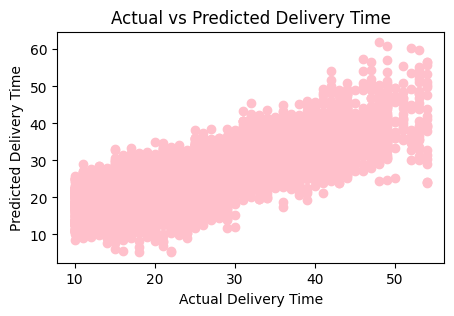

In [91]:
plt.figure(figsize=(5,3))

plt.scatter(y_test, y_pred,color='pink')

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")

plt.show()

The scatter plot indicates that the Linear Regression model captures the general trend of delivery times but exhibits significant prediction errors. 
The wide spread of points and the R² score of 0.215 suggest that the model has limited explanatory power. Additional relevant features would be required
to improve prediction accuracy.

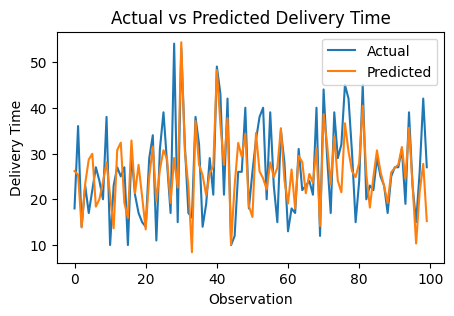

In [92]:
plt.figure(figsize=(5,3))

plt.plot(y_test.values[:100], label='Actual')
plt.plot(y_pred[:100], label='Predicted')

plt.xlabel("Observation")
plt.ylabel("Delivery Time")
plt.title("Actual vs Predicted Delivery Time")

plt.legend()

plt.show()

The predicted delivery times generally follow the trend of the actual delivery times, indicating that the Linear Regression model captures the overall
pattern but shows noticeable deviations in several observations.

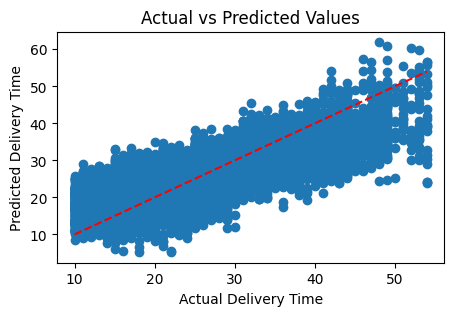

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Values")

plt.show()

The scatter plot shows that the Linear Regression model captures the general relationship between actual and predicted delivery times, but the wide 
dispersion of points from the ideal prediction line indicates limited prediction accuracy.

## Deployement

In [94]:
import joblib

In [95]:
joblib.dump(
    lr,
    "linear_regression_model.pkl"
)

['linear_regression_model.pkl']